In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [72]:
df = pd.read_csv(r"E:\codes\data_science\churn_prediction\notebook\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
df.shape

(7043, 21)

In [74]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [75]:
df.drop(["customerID"], inplace = True, axis = 1)

In [76]:
def percentage_plot(df, group, target):
    """
    Function to generate percentage bar plot between a feature and target variable
    """
    # Calculate percentage
    temp_df = (df.groupby([group, target]).size() /
               df.groupby(group)[target].count()).reset_index(name='percentage')

    plt.figure(figsize=(6,4))
    
    sns.barplot(x=group, y='percentage', hue=target, data=temp_df,
                palette=["green", "darkred"])
    
    plt.ylabel("Percentage")
    plt.xlabel(group)
    plt.title(f"{group} vs {target} (Percentage)")
    
    plt.show()

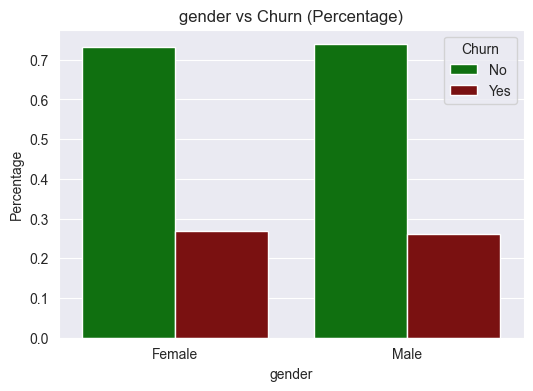

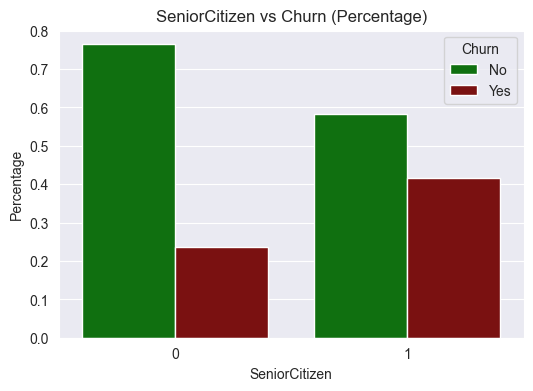

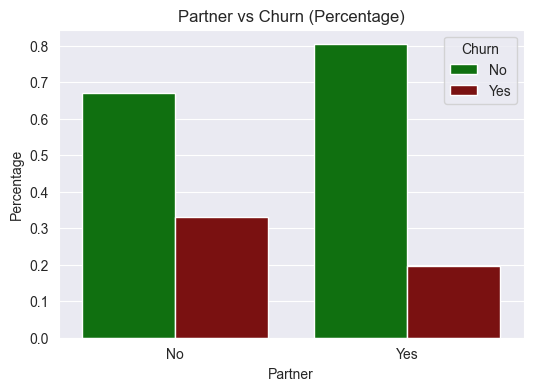

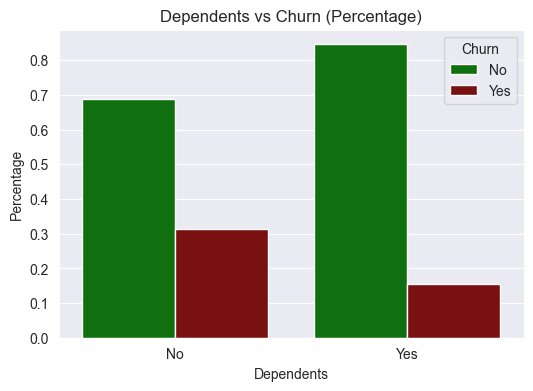

In [77]:
percentage_plot(df, "gender", "Churn")
percentage_plot(df, "SeniorCitizen", "Churn")
percentage_plot(df, "Partner", "Churn")
percentage_plot(df, "Dependents", "Churn")

In [78]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'Yes') & (df.Dependents == 'Yes')].Churn.value_counts()

Churn
No     1437
Yes     229
Name: count, dtype: int64

In [79]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'Yes') & (df.Dependents == 'No')].Churn.value_counts()

Churn
No     921
Yes    242
Name: count, dtype: int64

In [80]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'No') & (df.Dependents == 'Yes')].Churn.value_counts()

Churn
No     278
Yes     75
Name: count, dtype: int64

In [81]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'No') & (df.Dependents == 'No')].Churn.value_counts()

Churn
No     1872
Yes     847
Name: count, dtype: int64

In [82]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [83]:
df['tenure'].value_counts().head(10)

tenure
1     613
72    362
2     238
3     200
4     176
71    170
5     133
7     131
8     123
70    119
Name: count, dtype: int64

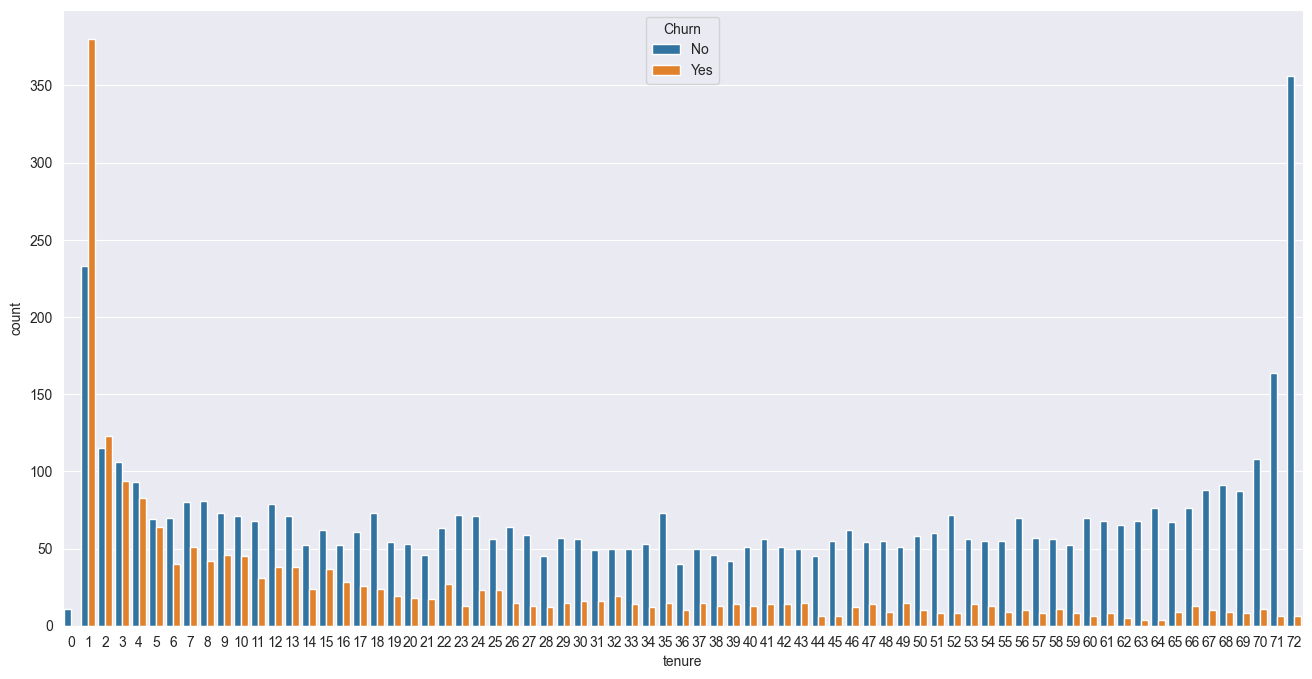

In [84]:
plt.figure(figsize=(16,8))
sns.countplot(x="tenure", hue="Churn", data=df)
plt.show()

In [85]:
bins = [0,12,24,36,48,60,72]
labels = [1,2,3,4,5,6]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

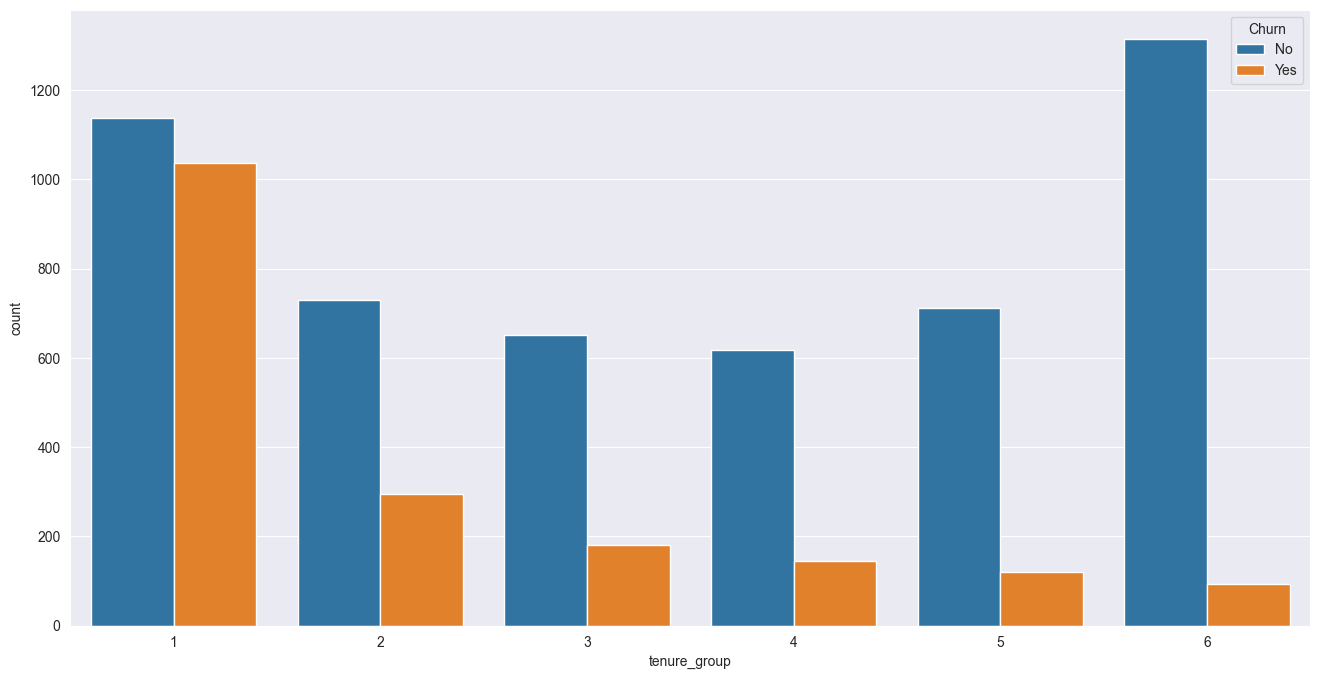

In [86]:
plt.figure(figsize=(16,8))
sns.countplot(x="tenure_group", hue="Churn", data=df)
plt.show()

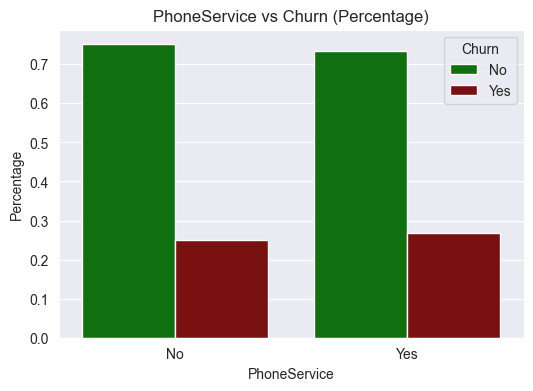

In [87]:
percentage_plot(df, "PhoneService", "Churn")

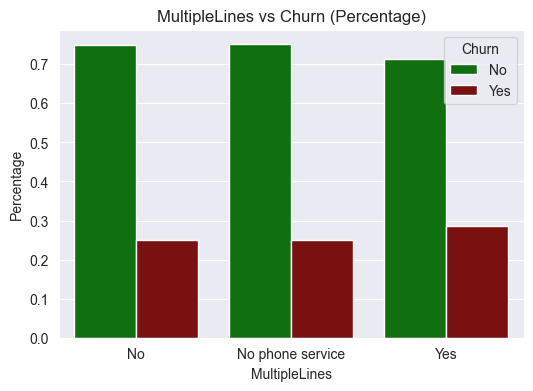

In [88]:
percentage_plot(df, "MultipleLines", "Churn")

In [89]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group'],
      dtype='object')

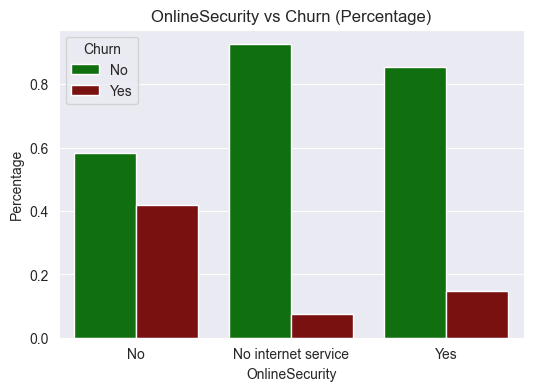

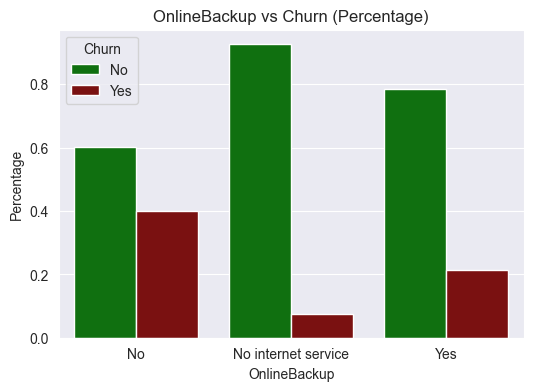

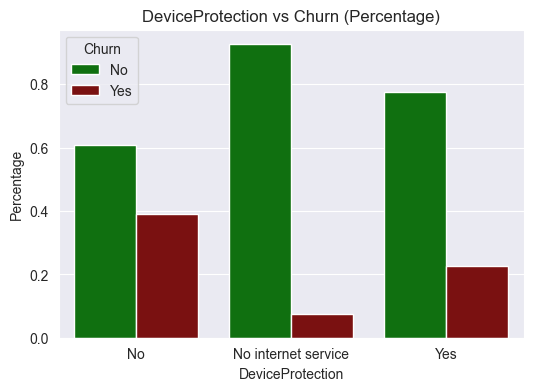

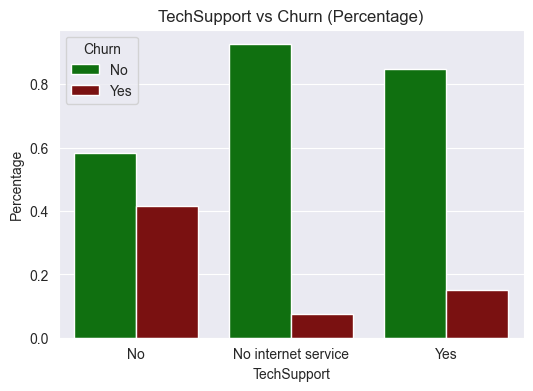

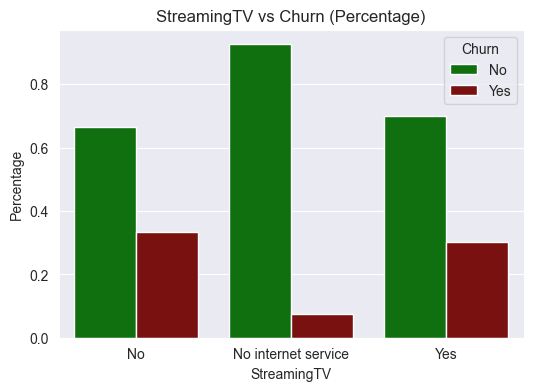

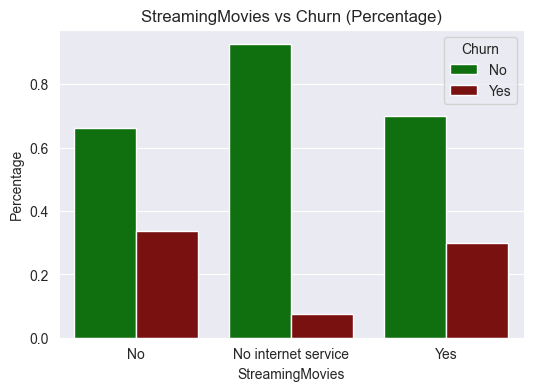

In [90]:
percentage_plot(df, "OnlineSecurity", "Churn")
percentage_plot(df, "OnlineBackup", "Churn")
percentage_plot(df, "DeviceProtection", "Churn")
percentage_plot(df, "TechSupport", "Churn")
percentage_plot(df, "StreamingTV", "Churn")
percentage_plot(df, "StreamingMovies", "Churn")

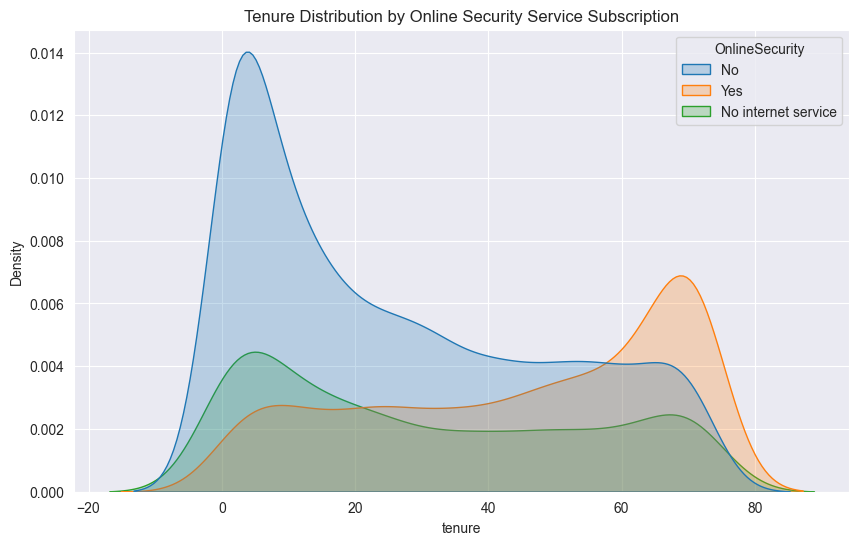

In [91]:
plt.figure(figsize=(10,6))

sns.kdeplot(data=df, x="tenure", hue="OnlineSecurity", fill=True)

plt.title("Tenure Distribution by Online Security Service Subscription")
plt.show()

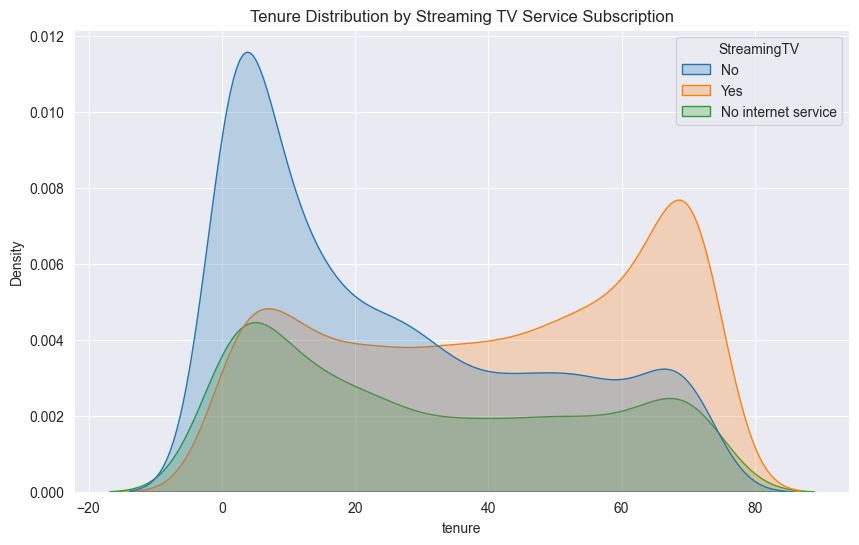

In [92]:
plt.figure(figsize=(10,6))

sns.kdeplot(data=df, x="tenure", hue="StreamingTV", fill=True)

plt.title("Tenure Distribution by Streaming TV Service Subscription")
plt.show()

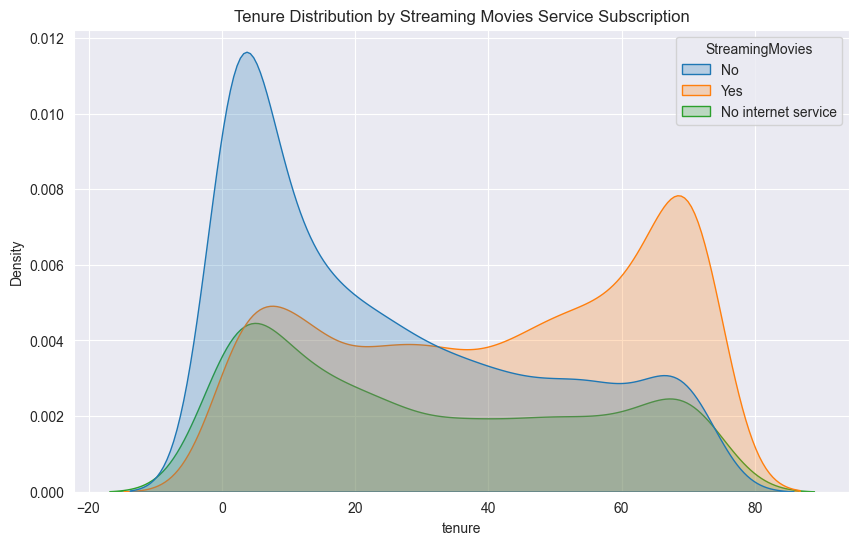

In [93]:
plt.figure(figsize=(10,6))

sns.kdeplot(data=df, x="tenure", hue="StreamingMovies", fill=True)

plt.title("Tenure Distribution by Streaming Movies Service Subscription")
plt.show()

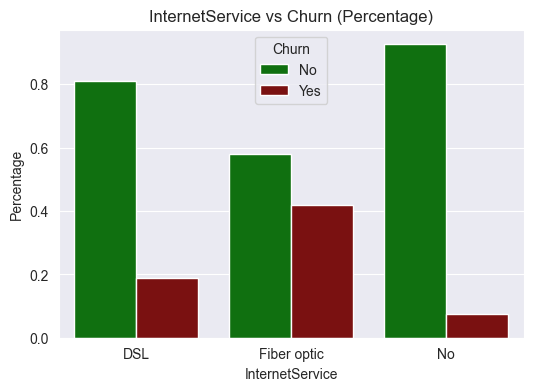

In [94]:
percentage_plot(df, "InternetService", "Churn")

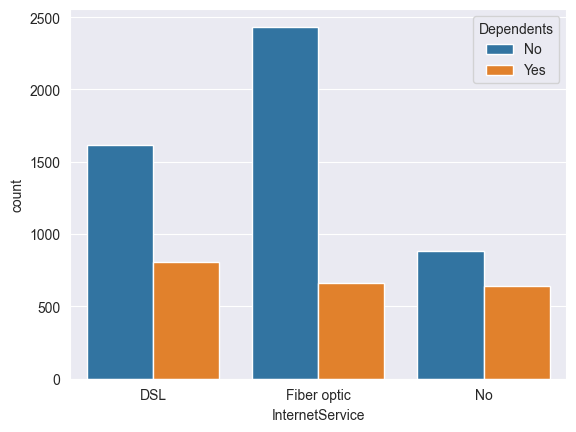

In [95]:
sns.countplot(x="InternetService", hue="Dependents", data=df)
plt.show()

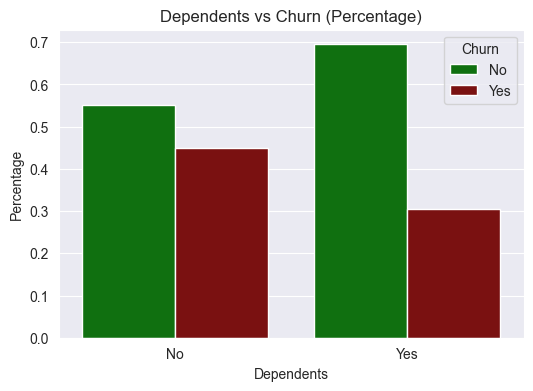

In [96]:
percentage_plot(df[df.InternetService == "Fiber optic"], "Dependents", "Churn")

<Axes: xlabel='InternetService', ylabel='count'>

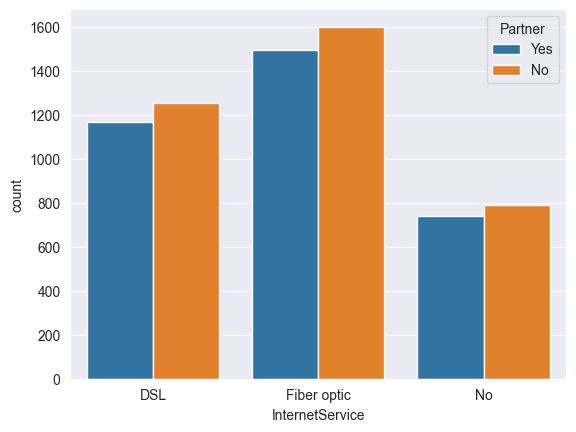

In [97]:
sns.countplot(x="InternetService", hue = "Partner",data=df)

<Axes: xlabel='InternetService', ylabel='count'>

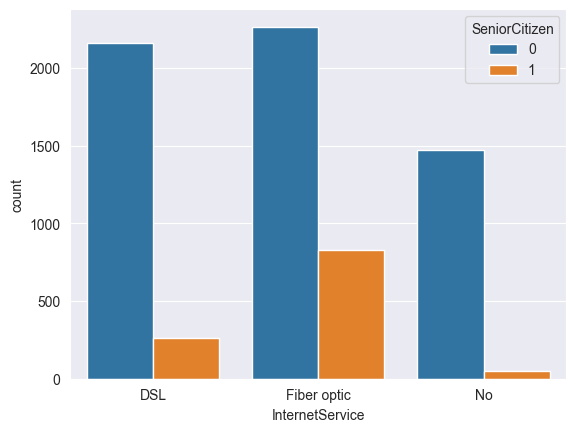

In [98]:
sns.countplot(x="InternetService", hue = "SeniorCitizen",data=df)

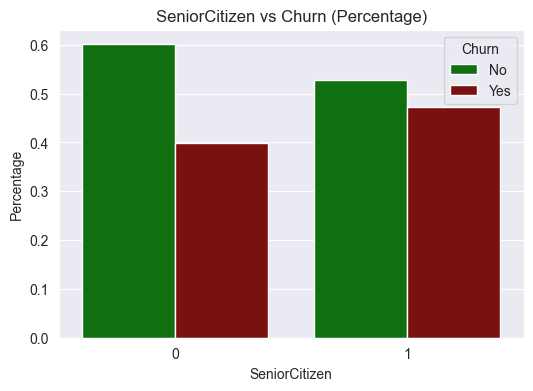

In [99]:
percentage_plot(df[df.InternetService == "Fiber optic"], "SeniorCitizen", "Churn")

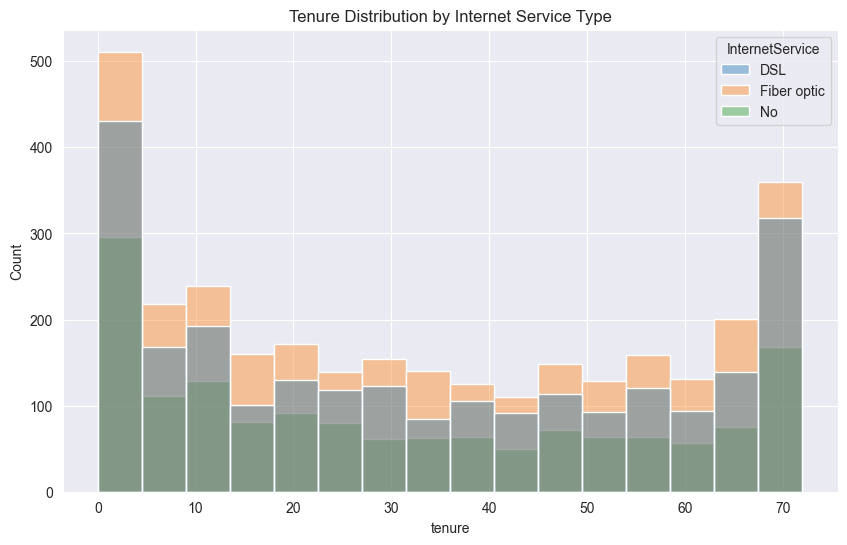

In [100]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x="tenure", hue="InternetService", alpha=0.4)

plt.title("Tenure Distribution by Internet Service Type")
plt.show() 

In [101]:
df[df.InternetService == 'No'].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
11,Male,0,No,No,16,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),18.95,326.8,No,2
16,Female,0,No,No,52,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,1022.95,No,5
21,Male,0,Yes,No,12,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.80,202.25,No,1
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes,1
33,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.20,20.2,No,1


In [102]:
df[df.InternetService == 'No'].OnlineSecurity.value_counts()


OnlineSecurity
No internet service    1526
Name: count, dtype: int64

In [103]:
df[df.InternetService == 'No'].OnlineBackup.value_counts()


OnlineBackup
No internet service    1526
Name: count, dtype: int64

In [104]:
df[df.InternetService == 'No'].DeviceProtection.value_counts()


DeviceProtection
No internet service    1526
Name: count, dtype: int64

In [105]:
df[df.InternetService == 'No'].TechSupport.value_counts()


TechSupport
No internet service    1526
Name: count, dtype: int64

In [106]:
df[df.InternetService == 'No'].StreamingMovies.value_counts()


StreamingMovies
No internet service    1526
Name: count, dtype: int64

In [107]:
df[df.InternetService == 'No'].StreamingTV.value_counts()


StreamingTV
No internet service    1526
Name: count, dtype: int64

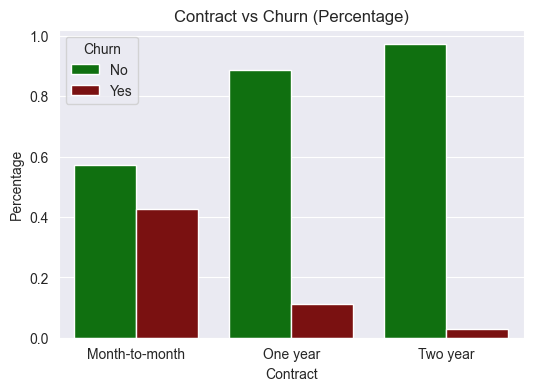

In [108]:
percentage_plot(df, "Contract", "Churn")

<Axes: xlabel='InternetService', ylabel='count'>

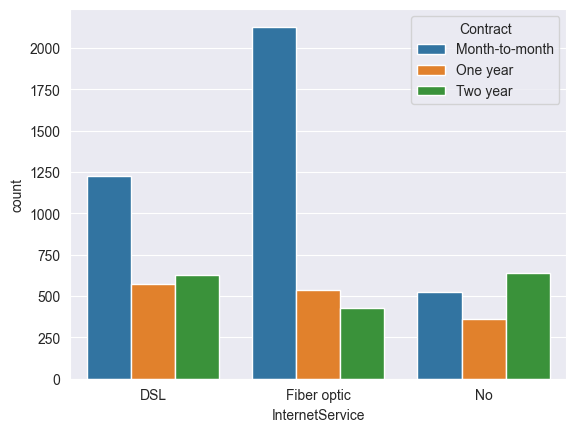

In [109]:
sns.countplot(x="InternetService", hue = "Contract",data=df)

Text(0, 0.5, 'Churn Percentage')

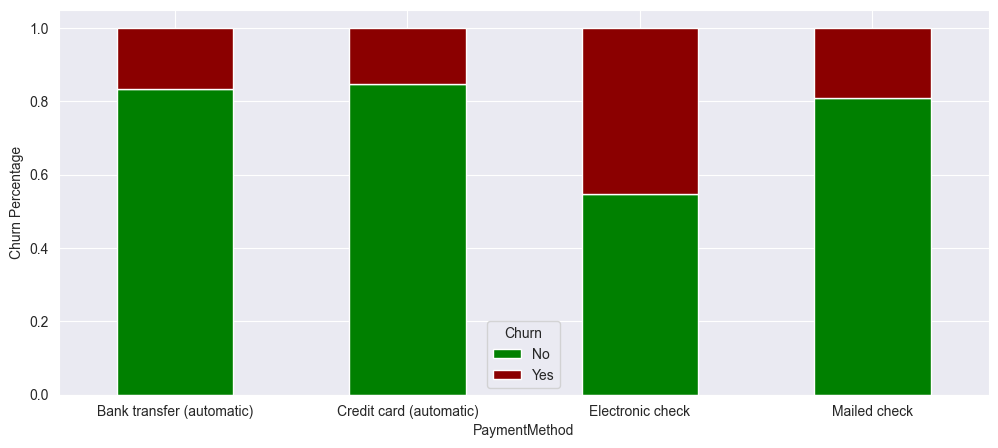

In [110]:
group = "PaymentMethod"
target = "Churn"
fig, ax = plt.subplots(figsize = (12,5))
temp_df = (df.groupby([group, target]).size()/df.groupby(group)[target].count()).reset_index().pivot(columns=target, index=group, values=0)
temp_df.plot(kind='bar', stacked=True, ax = ax, color = ["green", "darkred"])
ax.xaxis.set_tick_params(rotation=0)
ax.set_xlabel(group)
ax.set_ylabel('Churn Percentage')

<Axes: xlabel='PaymentMethod', ylabel='count'>

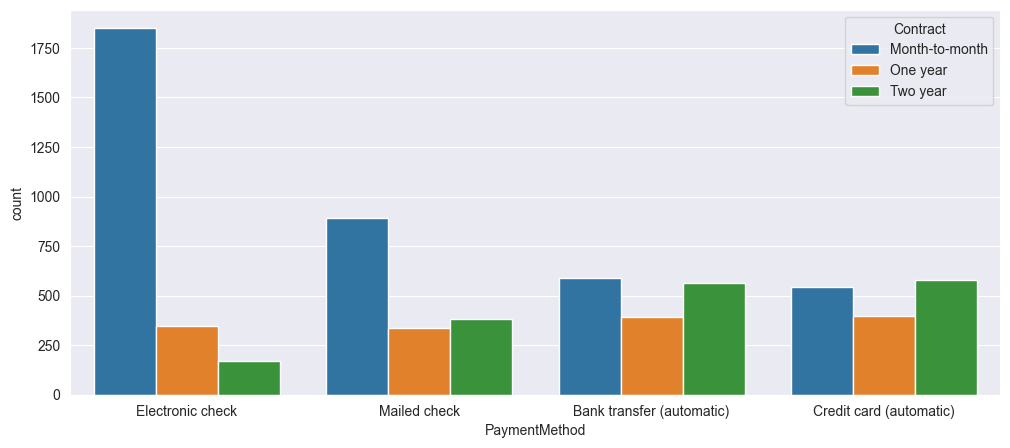

In [111]:
fig, ax = plt.subplots(figsize = (12,5))
sns.countplot(x="PaymentMethod", hue = "Contract",data=df, ax = ax)

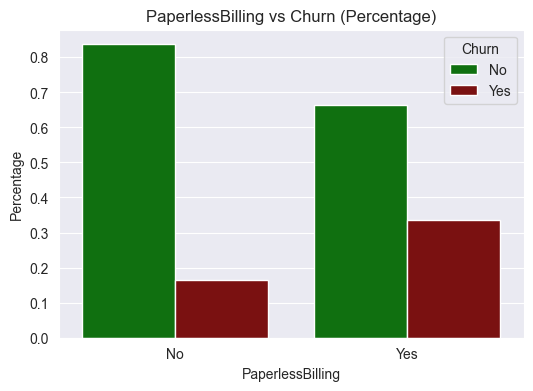

In [112]:
percentage_plot(df, "PaperlessBilling", "Churn")

In [113]:
df.TotalCharges.describe()

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object

In [114]:
df['TotalCharges'] = df["TotalCharges"].replace(" ",np.nan)
df['TotalCharges'].isna().sum() 

11

In [115]:
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,NaN
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,NaN
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,NaN
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,NaN
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,NaN
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,NaN
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,NaN
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,NaN
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,NaN
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,NaN


In [116]:
df.loc[df["TotalCharges"].isnull(), 'TotalCharges'] = 0
df.isnull().any().any()

True

In [117]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
tenure_group        11
dtype: int64

In [118]:
df.isnull().sum()[df.isnull().sum() > 0]

tenure_group    11
dtype: int64

In [120]:
bins = [0,12,24,36,48,60,72]
labels = [1,2,3,4,5,6]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

In [121]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_group        0
dtype: int64

In [122]:
df.loc[df["TotalCharges"].isnull(), 'TotalCharges'] = 0
df.isnull().any().any()

False

In [123]:
df['TotalCharges'] = df["TotalCharges"].astype(float)

Churn = df[df.Churn=="Yes"]
Not_Churn = df[df.Churn=="No"]

Text(0.5, 0, 'Total Charges')

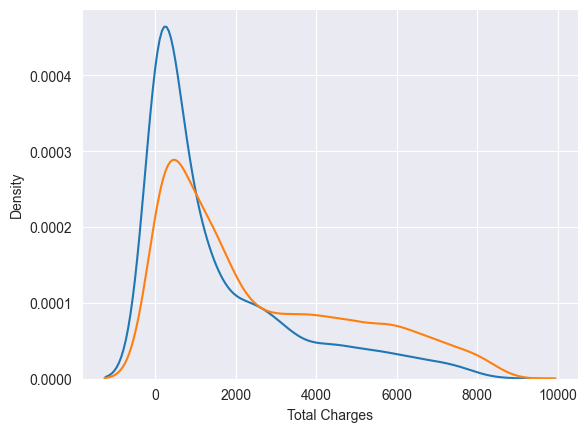

In [124]:
fig, ax = plt.subplots()
sns.kdeplot(Churn["TotalCharges"],label = "Churn", ax= ax)
sns.kdeplot(Not_Churn["TotalCharges"], label = "Not Churn", ax=ax)
ax.set_xlabel("Total Charges")

In [125]:
df.MonthlyCharges.describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [126]:
df.MonthlyCharges.isna().sum()

0

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

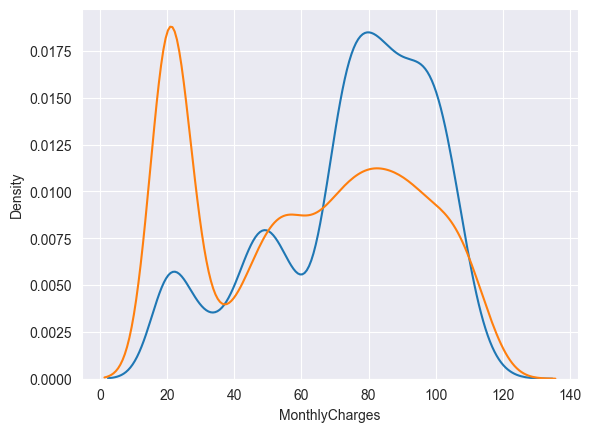

In [127]:
sns.kdeplot(Churn["MonthlyCharges"], label = "Churn")
sns.kdeplot(Not_Churn["MonthlyCharges"], label = "Not Churn")

In [128]:

np.corrcoef(df.TotalCharges, df.MonthlyCharges*df.tenure)

array([[1.        , 0.99956055],
       [0.99956055, 1.        ]])

In [131]:
def datapreparation(filepath):
    
    df = pd.read_csv(filepath)
    df.drop(["customerID"], inplace = True, axis = 1)
    
    df.TotalCharges = df.TotalCharges.replace(" ",np.nan)
    df.TotalCharges.fillna(0, inplace = True)
    df.TotalCharges = df.TotalCharges.astype(float)
    
    cols1 = ['Partner', 'Dependents', 'PaperlessBilling', 'Churn', 'PhoneService']
    for col in cols1:
        df[col] = df[col].apply(lambda x: 0 if x == "No" else 1)
   
    df.gender = df.gender.apply(lambda x: 0 if x == "Male" else 1)
    df.MultipleLines = df.MultipleLines.map({'No phone service': 0, 'No': 0, 'Yes': 1})
    
    cols2 = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in cols2:
        df[col] = df[col].map({'No internet service': 0, 'No': 0, 'Yes': 1})
    
    df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True).astype(int)

    return df

In [132]:
regression_df = datapreparation(r"E:\codes\data_science\churn_prediction\notebook\WA_Fn-UseC_-Telco-Customer-Churn.csv")
regression_df.head()

C:\Users\likit\AppData\Local\Temp\ipykernel_19376\520139875.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.TotalCharges.fillna(0, inplace = True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29,29,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,56,1889,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,53,108,1,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,42,1840,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,70,151,1,1,0,0,0,0,1,0
